In [1]:
# Import Libraries

import numpy as np # linear algebra
import pandas as pd # for data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns # for data visualization
import matplotlib.pyplot as plt # for data visulaization
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
!pip install catboost
import catboost
import xgboost
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.2 MB/s eta 0:00:00


ValueError: mount failed

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/데마 데이터/training.csv')
tdf = pd.read_csv('/content/drive/MyDrive/데마 데이터/test.csv')
ss = pd.read_csv('/content/drive/MyDrive/데마 데이터/sample_submission.csv')

In [ ]:
df

,patient_id,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,breast_cancer_diagnosis_desc,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D
0,475714,NaN,MEDICAID,CA,924,84,F,NaN,C50919,Malignant neoplasm of unsp site of unspecified...,...,12.871429,22.542857,10.100000,27.814286,11.200000,3.500000,52.237210,8.650555,18.606528,1
1,349367,White,COMMERCIAL,CA,928,62,F,28.49,C50411,Malig neoplm of upper-outer quadrant of right ...,...,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179,1
2,138632,White,COMMERCIAL,TX,760,43,F,38.09,C50112,Malignant neoplasm of central portion of left ...,...,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351,1
3,617843,White,COMMERCIAL,CA,926,45,F,NaN,C50212,Malig neoplasm of upper-inner quadrant of left...,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,0
4,817482,NaN,COMMERCIAL,ID,836,55,F,NaN,1749,"Malignant neoplasm of breast (female), unspeci...",...,15.276000,11.224000,1.946000,26.170213,12.088000,13.106000,41.356058,4.110749,11.722197,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12901,674178,White,NaN,OH,436,50,F,32.11,C50411,Malig neoplm of upper-outer quadrant of right ...,...,17.400000,23.600000,0.864706,19.841176,6.300000,6.247059,38.753055,8.068682,21.140731,1
12902,452909,NaN,COMMERCIAL,CA,945,50,F,NaN,C50912,Malignant neoplasm of unspecified site of left...,...,11.243210,7.837037,5.411250,34.700000,3.845679,5.671605,36.469947,6.265266,10.728732,1
12903,357486,NaN,COMMERCIAL,CA,926,61,F,29.24,C50912,Malignant neoplasm of unspecified site of left...,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,1
12904,935417,NaN,NaN,NY,112,37,F,31.00,1749,"Malignant neoplasm of breast (female), unspeci...",...,10.194737,18.642105,14.173684,42.502632,6.392105,1.755263,37.722740,7.879795,27.496367,0


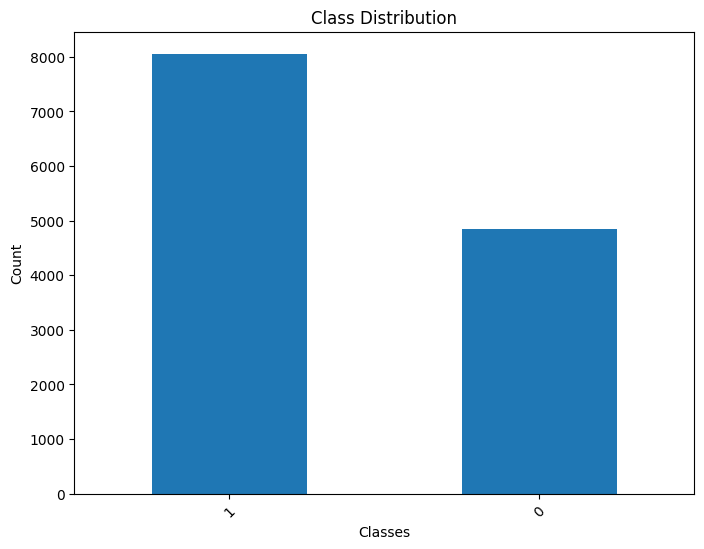

In [ ]:
target = "DiagPeriodL90D"

# Count the occurrences of each class
class_counts = df[target].value_counts()

# Plot the class distribution
plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

- # 데이터 전처리

## 새로운 환경변수 (N02 x PM25 x commute_time)  &  중복 컬럼 드랍

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd

# 필요한 컬럼
cols = ['N02', 'PM25', 'commute_time']

# 결측치 제거
df_clean = df[cols].dropna()
tdf_clean = tdf[cols].dropna()

# MinMax 정규화 (df 기준으로 fit)
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_clean[['N02', 'PM25', 'commute_time']]),
    columns=['N02_scaled', 'PM25_scaled', 'commute_scaled'],
    index=df_clean.index
)

# tdf 정규화 (transform만)
tdf_scaled = pd.DataFrame(
    scaler.transform(tdf_clean[['N02', 'PM25', 'commute_time']]),
    columns=['N02_scaled', 'PM25_scaled', 'commute_scaled'],
    index=tdf_clean.index
)

# 파생변수 추가
df["N02xOzonexPM25_scaled"] = np.nan
df.loc[df_clean.index, "N02xOzonexPM25_scaled"] = (
    df_scaled["N02_scaled"] * df_scaled["PM25_scaled"] * df_scaled["commute_scaled"]
)

tdf["N02xOzonexPM25_scaled"] = np.nan
tdf.loc[tdf_clean.index, "N02xOzonexPM25_scaled"] = (
    tdf_scaled["N02_scaled"] * tdf_scaled["PM25_scaled"] * tdf_scaled["commute_scaled"]
)


In [ ]:
# Drop some features
# List of columns to iterate over
columns_to_iterate = [col for col in df.columns if col not in ["patient_zip3", "N02xOzonexPM25_scaled"]]
# Iterate over each column
for col in columns_to_iterate:
    # Your code to operate on each column goes here
    df["check"]=df.groupby(["patient_zip3","N02xOzonexPM25_scaled"])[col].transform("nunique")
    if df["check"].max()==1:
        print("dropped ",col)
        df=df.drop(col,axis=1)
        tdf=tdf.drop(col,axis=1)
df=df.drop("check",axis=1)

## df, tdf 합치고 feature engineering

In [ ]:
# define target variable and categorical features
cat_cols = list(tdf.columns[tdf.dtypes=="object"])
cols = [col for col in tdf.columns if col not in ["patient_id"]]
tdf[target] = np.nan

# concatenate train and test set
df = pd.concat([df,tdf[df.columns]],axis=0)

In [ ]:
df["clust"]=(df.metastatic_cancer_diagnosis_code.str.len()==4).astype("int")
df["is_female"] = df.breast_cancer_diagnosis_desc.str.contains("female").astype("int")
df["is_female"].value_counts()

,count
is_female,
1,18665
0,33


## metastatic_code4 생성

In [ ]:
# meta 칼럼에서 5자리 값을 4자리로 변환
df['meta_code4'] = df['metastatic_cancer_diagnosis_code'].astype(str).apply(lambda x: x[:4] if len(x) >= 5 else x)

# 결과 확인
print(df['meta_code4'].nunique())
print(df['meta_code4'].value_counts())

#metastatic_cancer_diagnosis_code 드랍하기
df = df.drop(columns=['metastatic_cancer_diagnosis_code'])

27
meta_code4
C773    10223
C795     2760
C798     1196
C779     1095
C780      910
C787      533
C799      399
C793      389
C792      239
C771      226
C770      192
C782      117
C778      116
C786       57
C781       40
C772       39
C794       29
C796       27
C788       25
C785       25
C797       17
C775       14
C790        8
C791        7
C784        6
C783        5
C774        4
Name: count, dtype: int64


## 유방암 코드 매핑

In [ ]:
## ICD9 -> ICD10 매핑
## breast_cancer_diagnosis_desc
## breast_cancer_diagnosis_code

# 1. ICD9 -> ICD10 코드(code) 매핑
icd9_to_icd10 = {
    '1749': 'C50919', '1744': 'C50419',
    '1748': 'C50819', '1742': 'C50219',
    '1741': 'C50119', '1745': 'C50519',
    '1743': 'C50319', '1746': 'C50619',
    '19881': 'C7981', '1759': 'C50929'
}

# 2. ICD-10 ➝ 진단명(desc) 매핑
icd10_to_desc = {
    "C50919": "Malignant neoplasm of unsp site of unspecified female breast",
    "C50419": "Malig neoplasm of upper-outer quadrant of unsp female breast",
    "C50819": "Malignant neoplasm of ovrlp sites of unsp female breast",
    "C50219": "Malig neoplasm of upper-inner quadrant of unsp female breast",
    "C50119": "Malignant neoplasm of central portion of unsp female breast",
    "C50519": "Malig neoplasm of lower-outer quadrant of unsp female breast",
    "C50319": "Malig neoplasm of lower-inner quadrant of unsp female breast",
    "C50619": "Malignant neoplasm of axillary tail of unsp female breast",
    "C50929": "Malignant neoplasm of unsp site of unspecified male breast",
    "C7981": "Secondary malignant neoplasm of breast"
}


# 1-(1). ICD9 -> ICD10 코드(code) 매핑 적용
df['breast_cancer_diagnosis_code_mapped'] = df['breast_cancer_diagnosis_code'].astype(str).replace(icd9_to_icd10)

# 2-(2). ICD-10 ➝ 진단명(desc) 매핑 적용
df['breast_cancer_diagnosis_desc_mapped'] = df['breast_cancer_diagnosis_code_mapped'].map(icd10_to_desc).fillna(df['breast_cancer_diagnosis_desc'])

## tumor_site 생성

In [ ]:
# desc를 소문자로 변환하여 새로운 컬럼 생성
df['desc_lower'] = df['breast_cancer_diagnosis_desc_mapped'].str.lower()

# 위치 기반 파생 변수 생성
df['tumor_site'] = np.select(
    [
        df['desc_lower'].str.contains('inner'),
        df['desc_lower'].str.contains('outer') | df['desc_lower'].str.contains('axillary tail'),
        df['desc_lower'].str.contains('central portion') | df['desc_lower'].str.contains('nipple') | df['desc_lower'].str.contains('areola'),
        df['desc_lower'].str.contains('overlapping') | df['desc_lower'].str.contains('ovrlp'),
        df['desc_lower'].str.contains('unspecified') | df['desc_lower'].str.contains('unsp')
    ],
    [
        'Inner',
        'Outer',
        'Central',
        'Overlapping',
        'Unspecified'
    ],
    default='Unspecified'
)
df['tumor_site'].value_counts()

,count
tumor_site,
Unspecified,10171
Outer,4131
Overlapping,1833
Inner,1492
Central,1071


## breast_cancer_diagnosis_desc', 'breast_cancer_diagnosis_code 삭제

In [ ]:
df.drop(columns=['breast_cancer_diagnosis_desc', 'breast_cancer_diagnosis_code'], inplace=True)

## patient_race 결측치 unknown 처리

In [ ]:
# patient_race의 결측치를 'Unknown'으로 채우기
#df['patient_race'] = df['patient_race'].fillna('Unknown')
#랜덤포레스트 1.5버전이라 안해도 됌.

## Region, patient_zip3 'breast_cancer_diagnosis_code_mapped','breast_cancer_diagnosis_desc_mapped', 'desc_lower' 삭제

In [ ]:
df = df.drop(columns='Region')
df = df.drop(columns='patient_zip3')
df = df.drop(columns=[
    'breast_cancer_diagnosis_code_mapped',
    'breast_cancer_diagnosis_desc_mapped',
    'desc_lower'
])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18698 entries, 0 to 5791
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             18698 non-null  int64  
 1   patient_race           9412 non-null   object 
 2   payer_type             16135 non-null  object 
 3   patient_state          18626 non-null  object 
 4   patient_age            18698 non-null  int64  
 5   bmi                    5718 non-null   float64
 6   Division               18625 non-null  object 
 7   DiagPeriodL90D         12906 non-null  float64
 8   N02xOzonexPM25_scaled  18654 non-null  float64
 9   clust                  18698 non-null  int64  
 10  is_female              18698 non-null  int64  
 11  meta_code4             18698 non-null  object 
 12  tumor_site             18698 non-null  object 
dtypes: float64(3), int64(4), object(6)
memory usage: 2.0+ MB


## 범주형 원핫인코딩

In [ ]:
#범주형변수 원핫인코딩
cols_to_encode = [
    'patient_race',
    'payer_type',
    'patient_state',
    'Division',
    'meta_code4',
    'tumor_site'
]
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True, dtype=int)

In [ ]:
# do label encoding for categorical columns
le=LabelEncoder()
for col in cat_cols:
    try:
        df[col]=le.fit_transform(df[col]).astype("int")
        print(col)
    except:
        continue

In [ ]:
tdf=df[df[target].isna()]
df=df[df[target].notna()]
len(df),len(tdf)
#분리하는 코드

(12906, 5792)

- # 모델링

In [ ]:
# ▶ CatBoost
modela = CatBoostClassifier(iterations=500, silent=True, learning_rate=0.05, depth=10, eval_metric='AUC', random_seed=42)
# ▶ RandomForest
modelb = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
# ▶ XGBoost
model2a = XGBClassifier(
    learning_rate=0.1,
    max_depth=6,
    n_estimators=100,
    subsample=0.9
)

In [ ]:
# finalize features for training
drop_cols=["patient_id",target,"patient_zip3","patient_state"]
cols=list(set(df.columns)-set(drop_cols))

In [ ]:
# Define the number of folds
num_folds = 10
from sklearn.model_selection import StratifiedKFold
kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

In [ ]:
# use stacking method, define meta model
from sklearn.linear_model import LogisticRegression
meta_model = LogisticRegression()
meta_features=['pred1b','pred2','pred1']

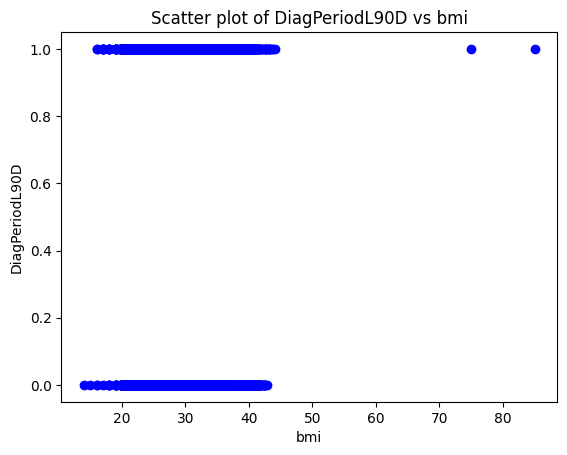

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Plotting
plt.scatter(df['bmi'], df[target], color='blue')
plt.xlabel('bmi')
plt.ylabel(target)
plt.title(f'Scatter plot of {target} vs bmi')
plt.savefig('bmi.png')
plt.show()


In [ ]:
# Initialize empty dataframe to store predictions from all folds
predictions_from_folds=pd.DataFrame()
# Iterate over folds
for fold, (train_index, val_index) in enumerate(kf.split(df, df[target])):
    dfx, efx = df.iloc[train_index], df.iloc[val_index]
    # train and make predictions on train set
    efx["pred1"] = modela.fit(dfx[cols].values, dfx[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred2"] = modelb.fit(dfx[cols].values, dfx[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred1b"] = model2a.fit(dfx[cols].values, dfx[target]).predict_proba(efx[cols].values)[:,1]
    # make predictions on test set
    tdf["pred1"] = modela.predict_proba(tdf[cols].values)[:,1]
    tdf["pred2"] = modelb.predict_proba(tdf[cols].values)[:,1]
    tdf["pred1b"] = model2a.predict_proba(tdf[cols].values)[:,1]
    # train meta-models and make final predictions
    tdf["pred"] = meta_model.fit(efx[meta_features], efx[target]).predict_proba(tdf[meta_features])[:, 1]
    predictions_from_folds=pd.concat([predictions_from_folds,tdf],axis=0)

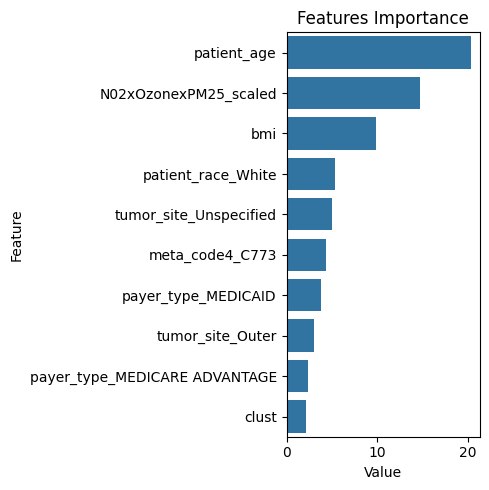

In [ ]:
# feature importance

feature_imp = pd.DataFrame(sorted(zip(modela.feature_importances_,cols)), columns=['Value','Feature'])
feature_imp=feature_imp.sort_values("Value",ascending=False)
feature_imp=feature_imp.head(10)
feature_imp["Feature"]=feature_imp["Feature"]
plt.figure(figsize=(5, 5))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False))
plt.title('Features Importance')
plt.tight_layout()
plt.savefig('cb_importances.png')
plt.show()

- # SUBMISSION

In [ ]:
# blend predictions from all folds
final_predictions=predictions_from_folds.groupby("patient_id").mean().reset_index()
final_predictions[target]=final_predictions["pred"].values
final_predictions[ss.columns].to_csv("final_predictions.csv",index=None)

In [ ]:

#  patient_id 기준으로 merge (왼쪽 기준: ss 순서 유지)
submission = ss.merge(final_predictions[['patient_id', 'pred']], on='patient_id', how='left')

#  target 컬럼에 예측값 복사
submission[target] = submission['pred']

#  필요 없는 'pred' 컬럼 제거
submission = submission[ss.columns]

#  지정된 순서로 CSV 저장
submission.to_csv("final_predictions_sorted.csv", index=False)


In [ ]:
from google.colab import files
files.download("final_predictions_sorted.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>